### Пет-проект: A/B-тест персонализированной системы рекомендации товаров

- Сайт с которого взял датасет: [Ссылка](https://ab-tests.ru)
- Ключ к данным для доступа и проверки метрик: 999543812

### Дизайн эксперимента

Некоторый сервис по продаже товаров онлайн.
Хотим увеличить выручку с клиента.
Добавили персонализированную систему рекомендаций товаров.
Оставили сервис без изменений у 42029 и добавили персонализированную систему рекомендаций товаров у 41441 человек.
Метрика - средний чек клиента за неделю.
Проверяем гипотезу о равенстве средних на уровне значимости 0.01.
Допустимая вероятность ошибки второго рода 0.1.
Минимальный детектируемый эффект равен 3% от среднего значения метрики.

In [168]:
# Загружаем все необходимые библиотеки для выполнения проекта
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

### Загрузка и проверка данных

In [53]:
# Первый взгляд на данные
df_transactions = pd.read_csv('transactions.csv')
df_users = pd.read_csv('users.csv')
display(df_transactions.head())
display(df_users.head())

,id,amount,date
0,0007baa91954971526e2c2afbf029a58,3864.0,2024-04-28
1,0007da0d99bdd6ae64c6860c2a7a52dd,5649.0,2024-04-25
2,000fb97df01782421d2666674f16f0c7,6119.0,2024-04-26
3,0016d807a4f2269a59f67ab8e9d9861e,1082.0,2024-04-25
4,00191029f816b6dacf06f011e9b0f52d,14434.0,2024-04-26


,id,group
0,692c3697f26f444268b6d2389332b31f,control
1,bfd90360060d34af4f7481e4d90837e4,control
2,f1b85853b6208f53a3e70f76f87a6bc2,control
3,813738d5ccbe5f61b83f0da19cea12d2,control
4,91cc087093c2fb2179db01a1cadfed50,control


In [60]:
# Быстрая проверка данных таблицы транзакций
print(df_transactions.shape)
print(df_transactions.dtypes)
print(df_transactions.isna().sum())
print(df_transactions.duplicated().sum())

(18770, 3)
id            str
amount    float64
date          str
dtype: object
id        0
amount    0
date      0
dtype: int64
0


In [97]:
# Быстрая проверка данных таблицы юзеров
print(df_users.shape)
print(df_users.dtypes)
print(df_users.isna().sum())
print(df_users.duplicated().sum())

(83470, 2)
id       str
group    str
dtype: object
id       0
group    0
dtype: int64
0


In [98]:
# Проверка, что нет отрицательных значений в столбце amount
print((df_transactions['amount'] < 0).sum())

0


In [62]:
# Проверяем баланс групп: реально ли было разделение пользователей 50% на 50:
amount_group = len(df_users)
control_group_cnt = len(df_users[df_users['group'] == 'control'])
treatment_group_cnt = len(df_users[df_users['group'] == 'treatment'])

print(f"total amount: {amount_group}")
print(f"control: {control_group_cnt} treatment: {treatment_group_cnt}")
print(f"control: {round((control_group_cnt / amount_group) * 100, 2)}% treatment: {round((treatment_group_cnt / amount_group) * 100, 2)}%")



total amount: 83470
control: 42029 treatment: 41441
control: 50.35% treatment: 49.65%


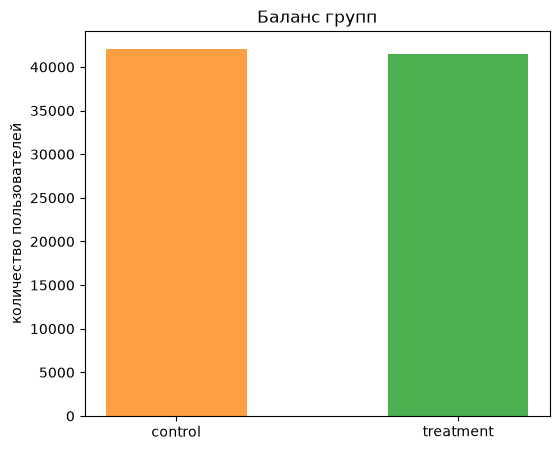

In [84]:
# Для наглядности решил сделать bar chart
groups = ['control', 'treatment']
counts = [control_group_cnt, treatment_group_cnt ]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(groups, counts, color=["#ff9f43", "#4caf50"], width=0.5)

ax.set_ylabel('количество пользователей')
ax.set_title('Баланс групп')
plt.show()


### Анализ выбросов

In [7]:
# Определяем IQR, нижнюю границу и верхнюю границу. И после определяем выбросы
df_sorted = df_transactions.sort_values('amount')
quartiles = df_sorted['amount'].quantile([0.25, 0.5, 0.75])
iqr = quartiles[0.75] - quartiles[0.25]
print(f"IQR: {iqr}")
lower_bound = quartiles[0.25] - 1.5 * iqr
high_bound = quartiles[0.75] + 1.5 * iqr
print(f"lower bound: {lower_bound} ", f"upper bound: {high_bound}", sep='\n')
anomalies = len(df_sorted[df_sorted['amount'] > high_bound])
print(f"number of anomalous results {anomalies}")


IQR: 3529.0
lower bound: -1701.5 
upper bound: 12414.5
number of anomalous results 404


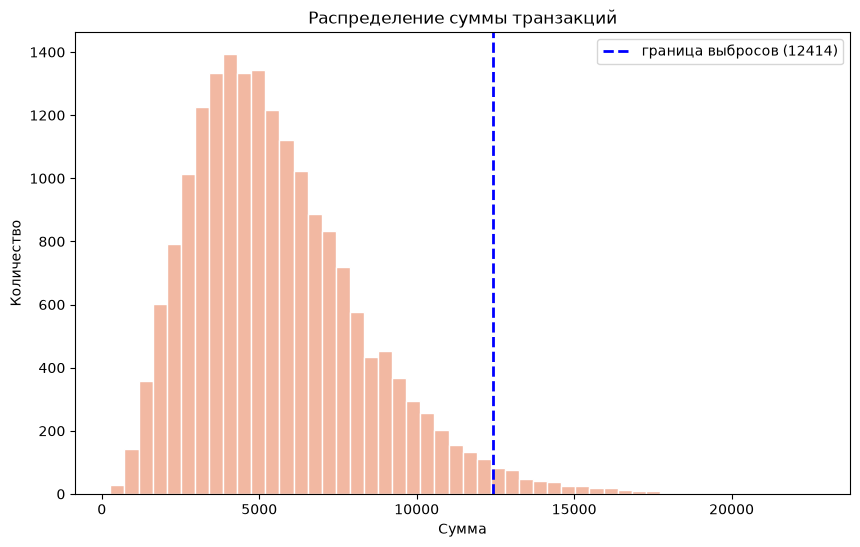

In [96]:
# Сделал график распределение суммы транзакций
fig, ax = plt.subplots(figsize=(10,6))
ax.hist(df_sorted['amount'], bins=50, color="#f2b8a2", edgecolor="white")
ax.axvline(high_bound, color="blue", linestyle="--", linewidth=2,
           label=f"граница выбросов ({high_bound:.0f})")

ax.legend(loc="upper right", frameon=True)
ax.set_title("Распределение суммы транзакций")
ax.set_xlabel("Сумма")
ax.set_ylabel("Количество")
plt.show()

In [100]:
# Для того чтобы принять решение о удалении выбросов, нам нужно понять: одинаковое ли количество выбросов находятся в тестовой и контрольной группе. Если они одинаковые, то мы их оставляем. Если они разные, то все-таки это выбросы и их нужно удалить
df_join = df_users.merge(df_transactions, how = 'left', on='id')
df_join = df_join.sort_values('amount')
df_users_control = df_join[(df_join['group'] == 'control') & (df_join['amount'] > high_bound)]
df_users_treatment = df_join[(df_join['group'] == 'treatment') & (df_join['amount'] > high_bound)]
df_users_control_cnt = len(df_users_control)
df_users_treatment_cnt = len(df_users_treatment)
print(df_users_control_cnt, df_users_treatment_cnt)

187 217


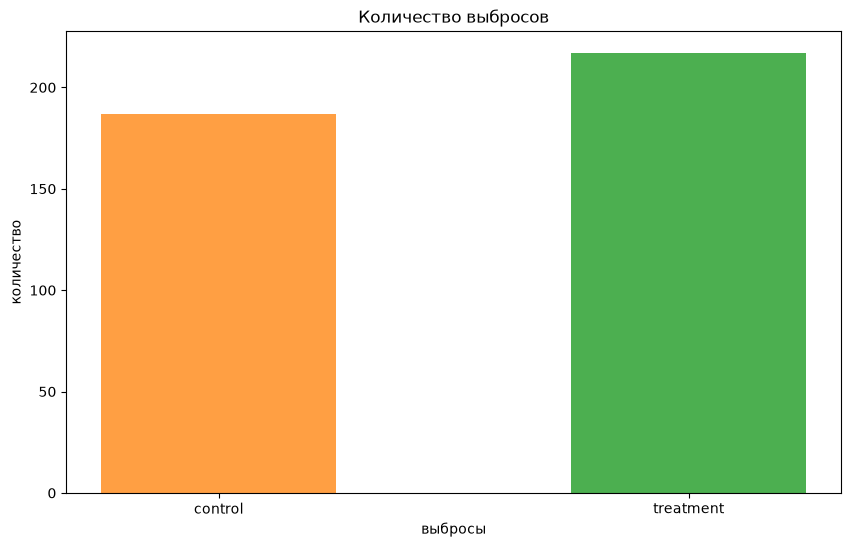

In [183]:
# Как мы видим выбросы распределены между группами сопоставимо и похожи на реальные покупки, поэтому не удаляем
groups = ['control','treatment']
counts = [df_users_control_cnt , df_users_treatment_cnt ]
fig, ax = plt.subplots(figsize=(10,6))
barr = ax.bar(groups, counts,color=["#ff9f43", "#4caf50"], width=0.5)
ax.set_title("Количество выбросов")
ax.set_ylabel("количество")
ax.set_xlabel("выбросы")
plt.show()

In [109]:
# Нужно проверить, укладываются ли данные в 7 дневный таймлайн
df_join['date'] = pd.to_datetime(df_join['date'])
print((df_join['date'].max() - df_join['date'].min()).days + 1)

7


### Расчёт главной метрики - средний чек

In [161]:
user_metrics = (
    df_transactions.groupby('id')['amount']
    .agg(revenue='sum', number_ts ='count', avg_check='mean')
    .reset_index()
)

df = df_users.merge(user_metrics, on='id', how='left')
df['revenue'] = df['revenue'].fillna(0)
df['number_ts'] = df['number_ts'].fillna(0)
df['converted'] = (df['number_ts'] > 0).astype(int)
display(df.head(30))

,id,group,revenue,number_ts,avg_check,converted
0,692c3697f26f444268b6d2389332b31f,control,0.0,0.0,NaN,0
1,bfd90360060d34af4f7481e4d90837e4,control,0.0,0.0,NaN,0
2,f1b85853b6208f53a3e70f76f87a6bc2,control,0.0,0.0,NaN,0
3,813738d5ccbe5f61b83f0da19cea12d2,control,0.0,0.0,NaN,0
4,91cc087093c2fb2179db01a1cadfed50,control,0.0,0.0,NaN,0
5,5e1ddb329fe4a1df569022870010c1bd,control,0.0,0.0,NaN,0
6,8bd1076b56d4b1de2c3e8e071397a9a1,control,0.0,0.0,NaN,0
7,133fc50f039ecbda2b933899f0ed007d,control,0.0,0.0,NaN,0
8,a6478f432502c18e73b015a442ccc6c6,control,4308.0,1.0,4308.0,1
9,2d7bfeb9e6c7b423f5c4102c5e8b5eb7,control,0.0,0.0,NaN,0


In [162]:
# Посчитаем средний чек пользователя по группам
avg_check_per_group =(
    df.groupby('group')['avg_check'].mean()
)
print(avg_check_per_group)
print('')
diff_abs = avg_check_per_group['treatment'] - avg_check_per_group['control']
diff_pct = (avg_check_per_group['treatment'] - avg_check_per_group['control']) / avg_check_per_group['control'] * 100

print(f"Разница между control и treatment: {round(diff_abs, 2)}, в % {round(diff_pct, 2)}%")

group
control      5512.281988
treatment    5656.643268
Name: avg_check, dtype: float64

Разница между control и treatment: 144.36, в % 2.62%


In [163]:
# Применим статистический критерий
control = df[df['group'] == 'control']['avg_check']
treatment = df[df['group'] == 'treatment']['avg_check']
delta_mean = np.mean(treatment) - np.mean(control)
print(f"delta_mean={delta_mean}")
stats.ttest_ind(control,treatment, nan_policy='omit')

delta_mean=144.36128019845728


TtestResult(statistic=np.float64(-3.588191350440993), pvalue=np.float64(0.00033382737424275693), df=np.float64(18768.0))

Получается, что альфа > p-value и мы делаем вывод, что разница статистически значима

### Расчет второстепенной метрики - вовлеченности (конверсия в покупку)

In [174]:
# Так как конверсия это бинарная метрика, мы используем z-тест
conv = df.groupby('group')['converted'].agg(['sum', 'count', 'mean'])
z_stat, p_conv = proportions_ztest(conv['sum'].values, conv['count'].values)
display(conv)
print(z_stat, p_conv)
print(((conv.loc['treatment'] - conv.loc['control']) * 100))

,sum,count,mean
group,,,
control,8855,42029,0.210688
treatment,9915,41441,0.239256


-9.884385283215503 4.8655879811294955e-23
sum      106000.000000
count    -58800.000000
mean          2.856795
dtype: float64


Альфа у нас опять > p-value, разница статистически значима. Данные показали рост конверсии в 2.86 %

### Выводы

Персонализированная система рекомендаций товаров показала статистически значимый положительный эффект по главной и второстепенной метрике:
- Средний чек показал рост с 5512.28 до 5656.64 (+2.62%). Эти значения статистически значимы. Но эффект оказался ниже заявленного бизнесом показателя.
- Вовлеченность (конверсия в покупку) показала рост с 21.07% до 23.93%. Эти значения тоже статистически значимы. Относительный рост + 13.6%.

Рекомендация: нужно внедрить систему на всех пользователей, но с оговоркой, что весь эффект обеспечен ростом вовлечённости, а не размером чека.
